In [2]:
import glob
import torch
import soxr
import numpy as np
import torch.nn.functional as F

from nnAudio.features import CQT, STFT
from src.utils import load_audio, speed_up, get_spectrum, get_fakeprints, get_freqs, get_freqs_mask


DEVICE = torch.device("cpu")

N_FFT = 1 << 14
SR = 44100
BINS_PER_OCTAVE = 96
AREA = 20
FREQ_RANGE = [5000, 16000]
FMIN = 32.7
SHOW_AI = True
TRANSFORM = "stft"

ai_dir = "/Users/emiledugelay/datasets/sunov5/"
human_dir = "/Users/emiledugelay/datasets/fma_small/"
data_dir = ai_dir if SHOW_AI else human_dir

hop_length = N_FFT // 2
fmax = SR / 2  # Maximum frequency that can be represented

log = (TRANSFORM == "cqt")
freqs = get_freqs(n_fft=N_FFT, sr=SR, log=log, bins_per_octave=BINS_PER_OCTAVE, fmin=FMIN)
mask = get_freqs_mask(freqs, sr=SR, freq_range=FREQ_RANGE)
freqs = freqs.to(DEVICE)
freqs_crop = freqs[mask]

cqt_transform = CQT(
    sr=SR,
    hop_length=hop_length,
    fmin=FMIN,
    fmax=fmax,
    bins_per_octave=BINS_PER_OCTAVE,
    output_format="Magnitude",
    verbose=False,
).to(DEVICE)

stft_transform = STFT(
    sr=SR,
    n_fft=N_FFT,
    hop_length=hop_length,
    output_format="Magnitude",
    verbose=False,
).to(DEVICE)

file_paths = glob.glob(f"{data_dir}/**/*.mp3", recursive=True)
audio_paths = np.random.choice(file_paths, size=2, replace=False)

waveforms = []
for path in audio_paths:
    waveform, sr = load_audio(path)
    if sr != SR:
        print(f"Resampling {path} from {sr} Hz to {SR} Hz")
        waveform = soxr.resample(waveform.T, sr, SR, quality="VHQ").T
        waveform = torch.from_numpy(waveform)
    waveform = waveform.mean(dim=0, keepdim=True)
    waveforms.append(waveform)

waveform1 = waveforms[0]
waveform2 = waveforms[1]
print(f"Loaded {audio_paths[0]} with shape {waveform1.shape} and sample rate {SR}")
print(f"Loaded {audio_paths[1]} with shape {waveform2.shape} and sample rate {SR}")

/Users/emiledugelay/Machine-Learning/deezer/robust-deepfake-detector/.venv/lib/python3.13/site-packages/nnAudio/utils.py:429: SyntaxWarning: If fmax is given, n_bins will be ignored
  warnings.warn("If fmax is given, n_bins will be ignored", SyntaxWarning)


Resampling /Users/emiledugelay/datasets/sunov5/35e308f6e2821c4159e935ce7bbfa9bc4991d147920b5ee5a242f7fdb1b0e3e2.mp3 from 48000 Hz to 44100 Hz
Resampling /Users/emiledugelay/datasets/sunov5/614011f3c9640b4b0b197f4a23d2f1d956592f0375f756a1aa3faa362294c226.mp3 from 48000 Hz to 44100 Hz
Loaded /Users/emiledugelay/datasets/sunov5/35e308f6e2821c4159e935ce7bbfa9bc4991d147920b5ee5a242f7fdb1b0e3e2.mp3 with shape torch.Size([1, 7061291]) and sample rate 44100
Loaded /Users/emiledugelay/datasets/sunov5/614011f3c9640b4b0b197f4a23d2f1d956592f0375f756a1aa3faa362294c226.mp3 with shape torch.Size([1, 7779239]) and sample rate 44100


In [3]:
SPEED_FACTOR = 0.86553656

su_waveform1 = speed_up(waveform1, sr=SR, speed_factor=SPEED_FACTOR)

transform_fn = cqt_transform if TRANSFORM == "cqt" else stft_transform
spec1 = get_spectrum(transform_fn, waveform1)
su_spec1 = get_spectrum(transform_fn, su_waveform1)
spec2 = get_spectrum(transform_fn, waveform2)

spec1 = spec1.mean(dim=-1)
su_spec1 = su_spec1.mean(dim=-1)
spec2 = spec2.mean(dim=-1)

fp1 = get_fakeprints(spec1, area=AREA)
su_fp1 = get_fakeprints(su_spec1, area=AREA)
fp2 = get_fakeprints(spec2, area=AREA)

fp1 = fp1[:, mask]
su_fp1 = su_fp1[:, mask]
fp2 = fp2[:, mask]

# fp1 = torch.clip(fp1, None, 8.0)
# su_fp1 = torch.clip(su_fp1, None, 8.0)
# fp2 = torch.clip(fp2, None, 8.0)

fp1.shape, su_fp1.shape, fp2.shape

(torch.Size([1, 4087]), torch.Size([1, 4087]), torch.Size([1, 4087]))

Number of log bins: 3222
tensor([ 5000.0010,  5001.8066,  5003.6133,  ..., 15988.4551, 15994.2295,
        16000.0068]) tensor([ 5000.9600,  5002.7666,  5004.5732,  ..., 15986.3418, 15992.1113,
        15997.8848])


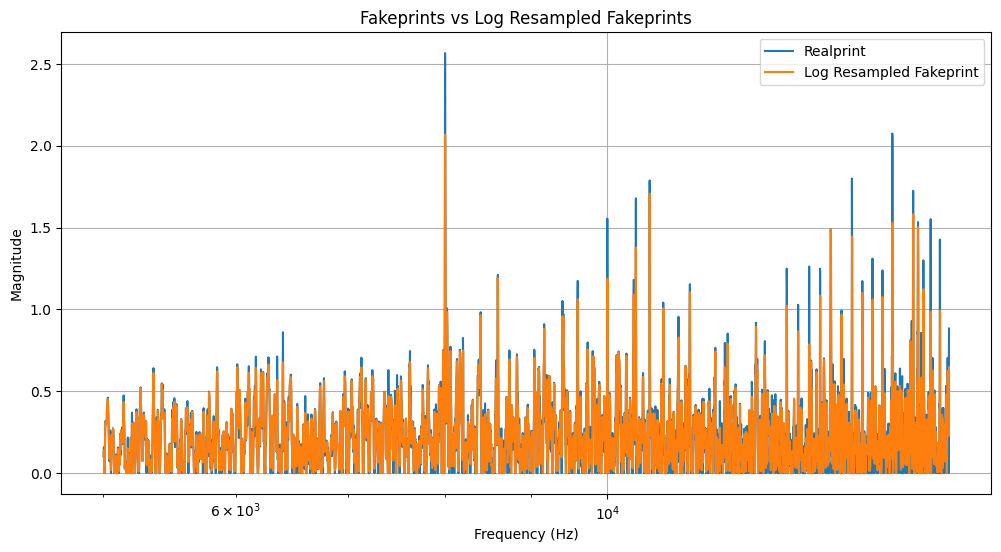

In [7]:
import math
from src.utils.fakeprints import get_freqs, get_freqs_mask

bins_per_octave = 96 * 20 # 1920
n_log_bins = int(math.ceil(bins_per_octave * math.log2(FREQ_RANGE[1] / FREQ_RANGE[0])))
print(f"Number of log bins: {n_log_bins}")

log_freqs = torch.logspace(
    math.log10(FREQ_RANGE[0]),
    math.log10(FREQ_RANGE[1]),
    steps=n_log_bins
)  # (n_log_bins,) in Hz

freqs_log = get_freqs(n_fft=N_FFT, sr=SR, log=True, bins_per_octave=bins_per_octave, fmin=FMIN)
mask_log = get_freqs_mask(freqs_log, sr=SR, freq_range=FREQ_RANGE)
freqs_log_crop = freqs_log[mask_log]
print(log_freqs, freqs_log_crop)

# Fractional indices into the linear STFT bins
freq_indices = (freqs_log_crop - freqs_crop[0]) / (freqs_crop[1] - freqs_crop[0])
freq_indices = freq_indices.clamp(0, len(freqs_crop) - 1)

# Precompute interpolation indices and weights
idx_low = freq_indices.long()
idx_high = (idx_low + 1).clamp(max=len(freqs_crop) - 1)
alpha = (freq_indices - idx_low.float())


# log resampling of the fakeprints
fp_log = (1 - alpha) * fp1[:, idx_low] + alpha * fp1[:, idx_high]  # (1, n_log_bins)
su_fp_log = (1 - alpha) * su_fp1[:, idx_low] + alpha * su_fp1[:, idx_high]  # (1, n_log_bins)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(freqs_crop, fp1[0].cpu(), label="Realprint")
plt.plot(freqs_log_crop, fp_log[0].cpu(), label="Log Resampled Fakeprint")
plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Fakeprints vs Log Resampled Fakeprints")
plt.legend()
plt.grid()
plt.show()



In [ ]:
import torch

def shift_spectre(spectre, decalage, dim=1):
    """
    Décale un tenseur de spectre le long d'une dimension donnée.
    
    Args:
        spectre (torch.Tensor): Le tenseur à décaler, ex: de forme (B, F).
        decalage (int): Le nombre de bins de décalage. Positif vers la droite, négatif vers la gauche.
        dim (int): La dimension des fréquences (1 par défaut pour (B, F)).
    """
    # Si le décalage est de 0, on ne fait rien pour économiser du calcul
    if decalage == 0:
        return spectre
        
    # 1. Décalage circulaire avec torch.roll
    spectre_decale = torch.roll(spectre, shifts=decalage, dims=dim)
    
    # 2. Remplacement des valeurs qui ont fait le tour (Wrap-around) par 0
    if decalage > 0:
        # Les hautes fréquences sont revenues à gauche (au début) : on les met à zéro
        spectre_decale[:, :decalage] = 0.0
    elif decalage < 0:
        # Les basses fréquences sont passées à droite (à la fin) : on les met à zéro
        spectre_decale[:, decalage:] = 0.0
        
    return spectre_decale

def apply_speed_mask(fp, speed_factor, freqs_log, freq_range):
    """
    When speed < 1.0, content above (fmax * speed_factor) is invalid.
    When speed > 1.0, content below (fmin * speed_factor) is invalid.
    
    fp:          (B, n_log_bins)
    speed_factor: float
    freqs_log:   (n_log_bins,) Hz values of log-resampled bins
    freq_range:  (2,) The frequency range (min, max) in Hz
    """
    if speed_factor < 1.0:
        valid_fmax = freq_range[1] * speed_factor
        mask = freqs_log <= valid_fmax  # (n_log_bins,)
    else:
        valid_fmin = freq_range[0] * speed_factor
        mask = freqs_log >= valid_fmin

    fp = fp * mask.float()  # zero out invalid bins
    return fp

In [ ]:
import matplotlib.pyplot as plt

bin_shifts = np.arange(-400, 400)  # Example bin shifts for 100 bins up and down
a = 2 ** (bin_shifts / bins_per_octave)  # Calculate the frequency scaling factor
print(f"Frequency scaling factors for bin shifts: {a}")

applied_bin_shift = bins_per_octave * np.log2(SPEED_FACTOR)  # Calculate the bin shift corresponding to the speed factor
print(f"Applied bin shift for speed factor {SPEED_FACTOR}: {applied_bin_shift:.2f} bins")


#fp_log = apply_speed_mask(fp_log, SPEED_FACTOR, log_freqs, FREQ_RANGE)
#su_fp_log = apply_speed_mask(su_fp_log, SPEED_FACTOR, log_freqs, FREQ_RANGE)

# plot fakeprints & sped up fakeprints
plt.figure(figsize=(18, 6))
plt.plot(log_freqs, fp_log[0].cpu(), label="Fakeprint")
plt.plot(log_freqs, su_fp_log[0].cpu(), label="Sped-up Fakeprint")
#plt.plot(freqs_crop, su_fp1[0].cpu(), label="Shifted Fakeprint", linestyle="dashed")
#plt.plot(log_freqs, shifted_fp_log[0].cpu(), label="Shifted Fakeprint", linestyle="dashed")
plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Fakeprints vs Sped-up Fakeprints (speed factor = {:.3f})".format(SPEED_FACTOR))
plt.legend()
plt.grid()
plt.show()

In [ ]:
fp_log_norm = F.normalize(fp_log, dim=-1)
su_fp_log_norm = F.normalize(su_fp_log, dim=-1)

cross_corr = F.conv1d(fp_log_norm.unsqueeze(1), fp_log_norm.unsqueeze(1), padding="same").squeeze()
cross_corr_su = F.conv1d(su_fp_log_norm.unsqueeze(1), fp_log_norm.unsqueeze(1), padding="same").squeeze()

lags = np.arange(-len(fp_log[0])//2 , len(fp_log[0])//2)

shifted_cross_corr = shift_spectre(cross_corr.unsqueeze(0), int(round(applied_bin_shift)), dim=1).squeeze(0)

lag_index = len(fp_log[0]) // 2 + int(round(applied_bin_shift))

print(f"argmax crosscorr: {torch.argmax(cross_corr_su).item()}")
print(f"predicted lag index: {lag_index}")

plt.figure(figsize=(18, 6))
plt.plot(lags, cross_corr, label="Auto-correlation")
plt.plot(lags, cross_corr_su, label="Cross-correlation")
#plt.plot(lags, shifted_cross_corr, label="Shifted Auto-correlation", linestyle="dashed")
plt.vlines(int(round(applied_bin_shift)), ymin=0, ymax=1, color="red", linestyle="dotted", label=f"Expected Shift ({applied_bin_shift:.2f} bins)")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.title("Correlation of Fakeprints")
plt.legend()
plt.grid()
plt.show()